# Dataset A models

Models evaluated:
- A neural network
- Random Forest 
- LightGBM

In [2]:
import numpy as np
import pandas as pd

dataset = pd.read_csv("lifestyle_dataset_balanced_under.csv")


In [2]:
dataset.head(10)

,Age,Alcohol Intake,BMI,Cardiovascular Disease,Gender,Physical Activity,Smoking Status
0,62,1,33.0,0,1,1,0
1,63,1,36.8,1,1,1,0
2,53,0,23.4,1,1,0,0
3,37,0,30.0,0,2,1,0
4,53,0,23.9,1,1,0,0
5,45,0,29.7,0,1,1,0
6,52,0,22.0,0,2,1,1
7,62,0,26.2,0,1,1,0
8,62,0,38.0,0,1,0,0
9,57,1,17.0,0,1,1,1


## Model Training 

In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import tensorflow as tf
import matplotlib.pyplot as plt

X = dataset.drop(['Cardiovascular Disease'], axis=1)
Y = dataset['Cardiovascular Disease']

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2, 
    random_state=42,
    stratify=Y 
)

#### 1) Neural Network 

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled.head()

,Age,Alcohol Intake,BMI,Gender,Physical Activity,Smoking Status
0,1.404374,-0.253202,1.097244,1.202141,-1.928560,-0.562944
1,-1.111799,3.949413,0.872599,1.202141,0.518521,1.776377
2,0.260659,-0.253202,0.578832,-0.831849,0.518521,-0.562944
3,0.108164,-0.253202,-0.285187,-0.831849,0.518521,-0.562944
4,0.794393,-0.253202,-0.855441,-0.831849,0.518521,-0.562944


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    #tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, Y_train, epochs=500)

Epoch 1/500


d:\miniConda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1604/1604 ━━━━━━━━━━━━━━━━━━━━ 2s 944us/step - accuracy: 0.6865 - loss: 0.6005
Epoch 2/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 1s 882us/step - accuracy: 0.6889 - loss: 0.5866
Epoch 3/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 1s 874us/step - accuracy: 0.6911 - loss: 0.5804
Epoch 4/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 3s 913us/step - accuracy: 0.6903 - loss: 0.5783
Epoch 5/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 1s 868us/step - accuracy: 0.6911 - loss: 0.5737
Epoch 6/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 2s 926us/step - accuracy: 0.6918 - loss: 0.5720
Epoch 7/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step - accuracy: 0.6936 - loss: 0.5702
Epoch 8/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - accuracy: 0.6926 - loss: 0.5677
Epoch 9/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step - accuracy: 0.6941 - loss: 0.5662
Epoch 10/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.6923 - loss: 0.5641
Epoch 11/500
1604/1604 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - accuracy: 0.6923 - loss: 0.5634
Epoch 12/

In [6]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - accuracy: 0.7078 - loss: 0.5408
Test Loss: 0.5408090949058533, Test Accuracy: 0.7077810764312744


In [8]:
scaledModel = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    #tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

scaledModel.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = scaledModel.fit(X_train_scaled, Y_train, epochs=500)

Epoch 1/500


C:\Users\adibs\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1433/1433 ━━━━━━━━━━━━━━━━━━━━ 2s 895us/step - accuracy: 0.7161 - loss: 0.5427
Epoch 2/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 1s 897us/step - accuracy: 0.7255 - loss: 0.5257
Epoch 3/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 1s 896us/step - accuracy: 0.7269 - loss: 0.5228
Epoch 4/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step - accuracy: 0.7271 - loss: 0.5210
Epoch 5/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7274 - loss: 0.5193
Epoch 6/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7286 - loss: 0.5182
Epoch 7/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7308 - loss: 0.5172
Epoch 8/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - accuracy: 0.7302 - loss: 0.5164
Epoch 9/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7298 - loss: 0.5157
Epoch 10/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7327 - loss: 0.5148
Epoch 11/500
1433/1433 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7334 - loss: 0.5144
Epoch 12/500
1433/143

In [9]:
loss, accuracy = scaledModel.evaluate(X_test_scaled, Y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.7485 - loss: 0.4993
Test Loss: 0.4993206262588501, Test Accuracy: 0.7485384941101074


359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step
Raw model:
Precision: 0.5356200527704486
Recall: 0.1891891891891892
ROC-AUC: 0.7408174958213031

Scaled model:
Precision: 0.5977945443993036
Recall: 0.3199751475613545
ROC-AUC: 0.7616317524127815


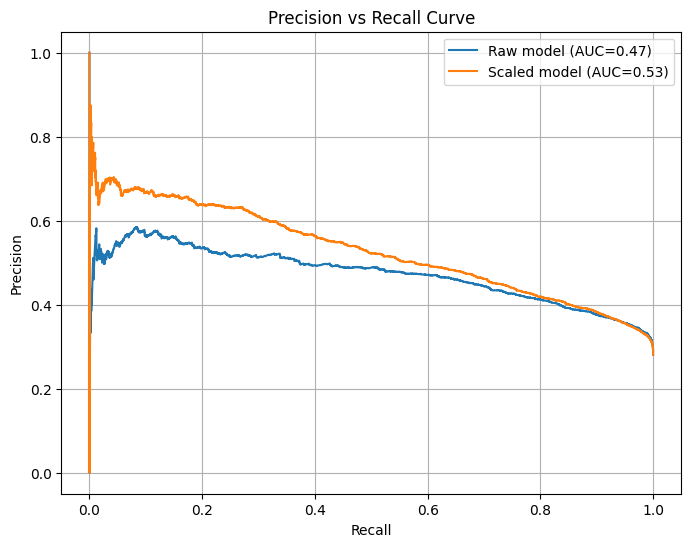

In [10]:
from sklearn.metrics import precision_recall_curve, auc

# Predict probabilities for the positive class
y_prob = model.predict(X_test)  # or model_raw.predict_proba(X_test)[:, 1] depending on framework
y_prob_scaled = scaledModel.predict(X_test_scaled)  # same note as above

# Compute precision, recall, and AUC for raw model
precision, recall, _ = precision_recall_curve(Y_test, y_prob)
aucModel = auc(recall, precision)

# Compute precision, recall, and AUC for scaled model
precision_scaled, recall_scaled, _ = precision_recall_curve(Y_test, y_prob_scaled)
auc_scaled = auc(recall_scaled, precision_scaled)

# Print precision, recall, and AUC summary (using average metrics if needed)
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# Binary predictions (default 0.5 threshold)
y_pred = (y_prob >= 0.5).astype(int)
y_pred_scaled = (y_prob_scaled >= 0.5).astype(int)

print("Raw model:")
print("Precision:", precision_score(Y_test, y_pred))
print("Recall:", recall_score(Y_test, y_pred))
print("ROC-AUC:", roc_auc_score(Y_test, y_prob))

print("\nScaled model:")
print("Precision:", precision_score(Y_test, y_pred_scaled))
print("Recall:", recall_score(Y_test, y_pred_scaled))
print("ROC-AUC:", roc_auc_score(Y_test, y_prob_scaled))

# Plot Precision-Recall curves
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Raw model (AUC={aucModel:.2f})')
plt.plot(recall_scaled, precision_scaled, label=f'Scaled model (AUC={auc_scaled:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


#### 2) Other models

In [7]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, Y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


In [4]:
lgbm_model = lgb.LGBMClassifier(objective = 'binary', n_estimators=100, learning_rate=0.05, random_state=42)
lgbm_model.fit(X_train, Y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]


------Performance Metrics------

LightGBM:
Accuracy: 0.7344
Precision: 0.7200
Recall: 0.7670
F1-score: 0.7428
ROC-AUC: 0.8023
              precision    recall  f1-score   support

           0       0.75      0.70      0.73      6353
           1       0.72      0.77      0.74      6353

    accuracy                           0.73     12706
   macro avg       0.74      0.73      0.73     12706
weighted avg       0.74      0.73      0.73     12706



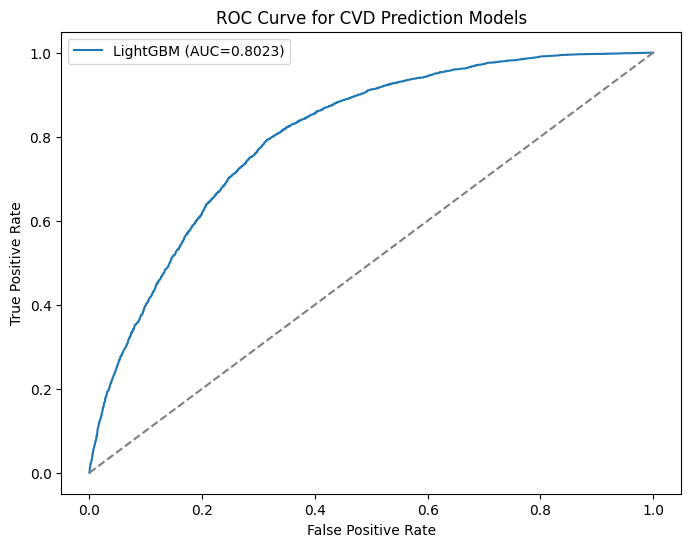

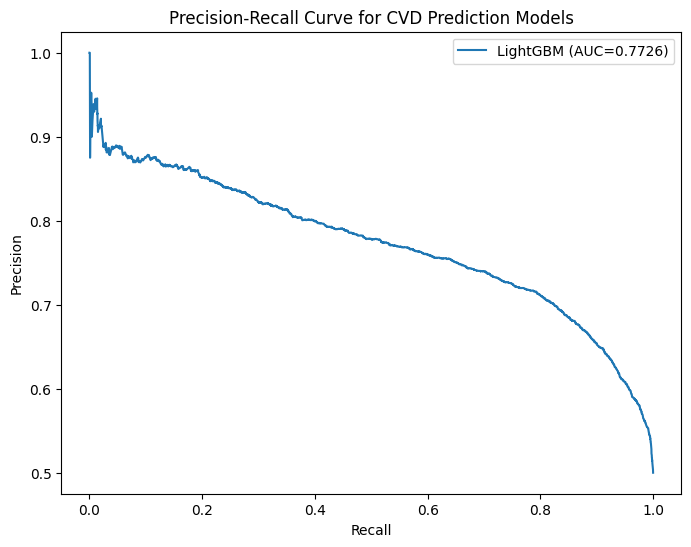

In [6]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, auc, classification_report
)

#y_prob_nn = model.predict(X_test).flatten()
#y_pred_nn = (y_prob_nn >= 0.5).astype(int)

#y_prob_scaled_nn = scaledModel.predict(X_test_scaled).flatten()
#y_pred_scaled_nn = (y_prob_scaled_nn >= 0.5).astype(int)

model_predictions = {
    #'Neural Network': (y_pred_nn, y_prob_nn),
    #'Scaled Neural Network': (y_pred_scaled_nn, y_prob_scaled_nn),
    #'Random Forest': (y_pred_rf, y_prob_rf),
    'LightGBM': (y_pred_lgbm, y_prob_lgbm)
}

print("\n------Performance Metrics------")
for model_name, (y_pred, y_proba) in model_predictions.items():
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred)
    rec = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    roc_auc = roc_auc_score(Y_test, y_proba)

    print(f"\n{model_name}:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(Y_test, y_pred))

plt.figure(figsize=(8, 6))
for model_name, (y_pred, y_proba) in model_predictions.items():
    fpr, tpr, _ = roc_curve(Y_test, y_proba)
    auc_score = roc_auc_score(Y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for CVD Prediction Models")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
for model_name, (y_pred, y_proba) in model_predictions.items():
    precision, recall, _ = precision_recall_curve(Y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{model_name} (AUC={pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for CVD Prediction Models")
plt.legend()
plt.show()

### Saving Models


✅ Models saved in 'Updated Models A' folder

LightGBM:
Accuracy: 0.7344
Precision: 0.7200
Recall: 0.7670
F1-score: 0.7428
ROC-AUC: 0.8023
PR-AUC: 0.7726
              precision    recall  f1-score   support

           0       0.75      0.70      0.73      6353
           1       0.72      0.77      0.74      6353

    accuracy                           0.73     12706
   macro avg       0.74      0.73      0.73     12706
weighted avg       0.74      0.73      0.73     12706



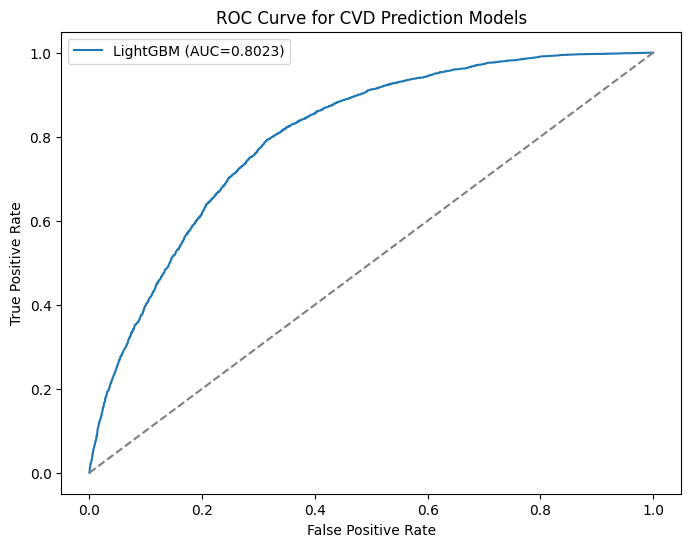

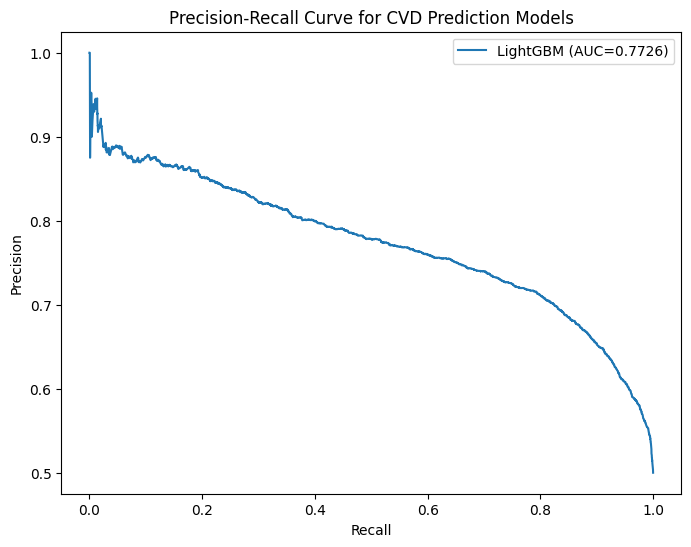

✅ Metrics summary saved as 'Lifestyle_metrics_summary.csv'


In [ ]:
import os
import joblib


os.makedirs("Updated Models A", exist_ok=True)

# Models dictionary for saving
models = {
    'LightGBM': lgbm_model
}

#model.save("Saved Models A/neural_network.keras")
#scaledModel.save("Saved Models A/scaled_neural_network.keras")

#joblib.dump(models['Random Forest'], "Saved Models A/random_forest.joblib")

if hasattr(models['LightGBM'], "booster_"):
    models['LightGBM'].booster_.save_model("Updated Models A/LifeStyle_model.txt")
else:
    joblib.dump(models['LightGBM'], "Updated Models A/lightgbm_model.joblib")

print("✅ Models saved in 'Updated Models A' folder")

# --------- PERFORMANCE METRICS & CSV EXPORT ---------
metrics_list = []

plt.figure(figsize=(8, 6))
for model_name, (y_pred, y_proba) in model_predictions.items():
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred)
    rec = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    roc_auc = roc_auc_score(Y_test, y_proba)

    # PR AUC
    precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    metrics_list.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })

    # Print metrics in console
    print(f"\n{model_name}:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(classification_report(Y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(Y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.4f})")

# Plot ROC Curve
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for CVD Prediction Models")
plt.legend()
plt.show()

# PR Curve Plot
plt.figure(figsize=(8, 6))
for model_name, (y_pred, y_proba) in model_predictions.items():
    precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_proba)
    pr_auc = auc(recall_curve, precision_curve)
    plt.plot(recall_curve, precision_curve, label=f"{model_name} (AUC={pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for CVD Prediction Models")
plt.legend()
plt.show()

# Save metrics as CSV
metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv("Lifestyle_metrics_summary.csv", index=False)
print("✅ Metrics summary saved as 'Lifestyle_metrics_summary.csv'")
